#  Solar Panel Fault Detection — No Images Required
**Dataset:** [PV Fault Dataset](https://github.com/clayton-h-costa/pv_fault_dataset) by Clayton H. Costa et al.  
**Paper:** *Monitoring System for Online Fault Detection and Classification in Photovoltaic Plants* — Sensors MDPI 2020  

This notebook trains a multiclass classifier to detect **5 operating states** of a solar PV system using only electrical and environmental sensor readings — no cameras, no images.

| Label | State |
|-------|-------|
| 0 | Normal Operation |
| 1 | Short-Circuit |
| 2 | Degradation |
| 3 | Open Circuit |
| 4 | Shadowing |

**Features used:** `vdc1` (string voltage), `idc1` (string current), `irr` (irradiance), `pvt` (PV module temperature)  
**Target:** `f_nv` (fault label)

## 1. Setup & Data Loading

In [1]:
!pip install scipy scikit-learn xgboost lightgbm matplotlib seaborn --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.io import loadmat
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb

# Plotting style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_palette('tab10')

FAULT_LABELS = {
    0: 'Normal',
    1: 'Short-Circuit',
    2: 'Degradation',
    3: 'Open Circuit',
    4: 'Shadowing'
}

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Option A: Download directly from GitHub (no manual upload needed)
# ─────────────────────────────────────────────────────────────────────────────
import urllib.request, os

BASE_URL = 'https://github.com/clayton-h-costa/pv_fault_dataset/raw/master/'

for fname in ['dataset_elec.mat', 'dataset_amb.mat']:
    if not os.path.exists(fname):
        print(f'Downloading {fname}...')
        urllib.request.urlretrieve(BASE_URL + fname, fname)
        print(f'  ✓ Saved {fname}')
    else:
        print(f'  ✓ {fname} already present')

  ✓ dataset_elec.mat already present
  ✓ dataset_amb.mat already present


In [10]:
ELEC_PATH = 'dataset_elec.mat'
AMB_PATH  = 'dataset_amb.mat'

elec = loadmat(ELEC_PATH)
amb  = loadmat(AMB_PATH)

print('Keys in elec:', [k for k in elec.keys() if not k.startswith('_')])
print('Keys in amb: ', [k for k in amb.keys()  if not k.startswith('_')])

# Flatten all arrays and build a single DataFrame
df = pd.DataFrame({
    'vdc1': elec['vdc1'].flatten(),   # Voltage String 1
    'idc1': elec['idc1'].flatten(),   # Current String 1
    'irr' : amb['irr'].flatten(),     # Irradiance (W/m²)
    'pvt' : amb['pvt'].flatten(),     # PV Module Temperature (°C)
    'fault': amb['f_nv'].flatten().astype(int),  # Target label
})

df['fault_name'] = df['fault'].map(FAULT_LABELS)

print(f'Dataset shape: {df.shape}')
df.head()


Keys in elec: ['idc1', 'idc2', 'vdc1', 'vdc2']
Keys in amb:  ['f_nv', 'irr', 'pvt']
Dataset shape: (1373798, 6)


,vdc1,idc1,irr,pvt,fault,fault_name
0,0.7143,0.0608,1.3729,2.3816,0,Normal
1,0.6944,0.0615,1.3604,2.3816,0,Normal
2,0.7110,0.0646,1.5118,2.3883,0,Normal
3,0.6991,0.0628,1.5534,2.3920,0,Normal
4,0.7035,0.0606,1.4355,2.3920,0,Normal


## 2. Exploratory Data Analysis

In [11]:
print('=== Basic Statistics ===')
print(df.describe().round(2))

print('\n=== Missing Values ===')
print(df.isnull().sum())

print('\n=== Class Distribution ===')
counts = df['fault_name'].value_counts()
for name, count in counts.items():
    pct = count / len(df) * 100
    print(f'  {name:<15} {count:>6} samples  ({pct:.1f}%)')

=== Basic Statistics ===
             vdc1        idc1         irr         pvt       fault
count  1373798.00  1373798.00  1373798.00  1373798.00  1373798.00
mean       135.12        2.28      257.61       22.77        0.58
std        136.33        3.19      353.12       14.23        1.39
min          0.38        0.04       -0.04       -1.65        0.00
25%          0.89        0.07        1.29       12.13        0.00
50%         37.78        0.11        1.74       18.49        0.00
75%        273.06        5.10      590.72       34.16        0.00
max        363.97        9.65     1085.92       60.82        4.00

=== Missing Values ===
vdc1          0
idc1          0
irr           0
pvt           0
fault         0
fault_name    0
dtype: int64

=== Class Distribution ===
  Normal          1162931 samples  (84.7%)
  Shadowing       188473 samples  (13.7%)
  Degradation      10371 samples  (0.8%)
  Open Circuit      6024 samples  (0.4%)
  Short-Circuit     5999 samples  (0.4%)


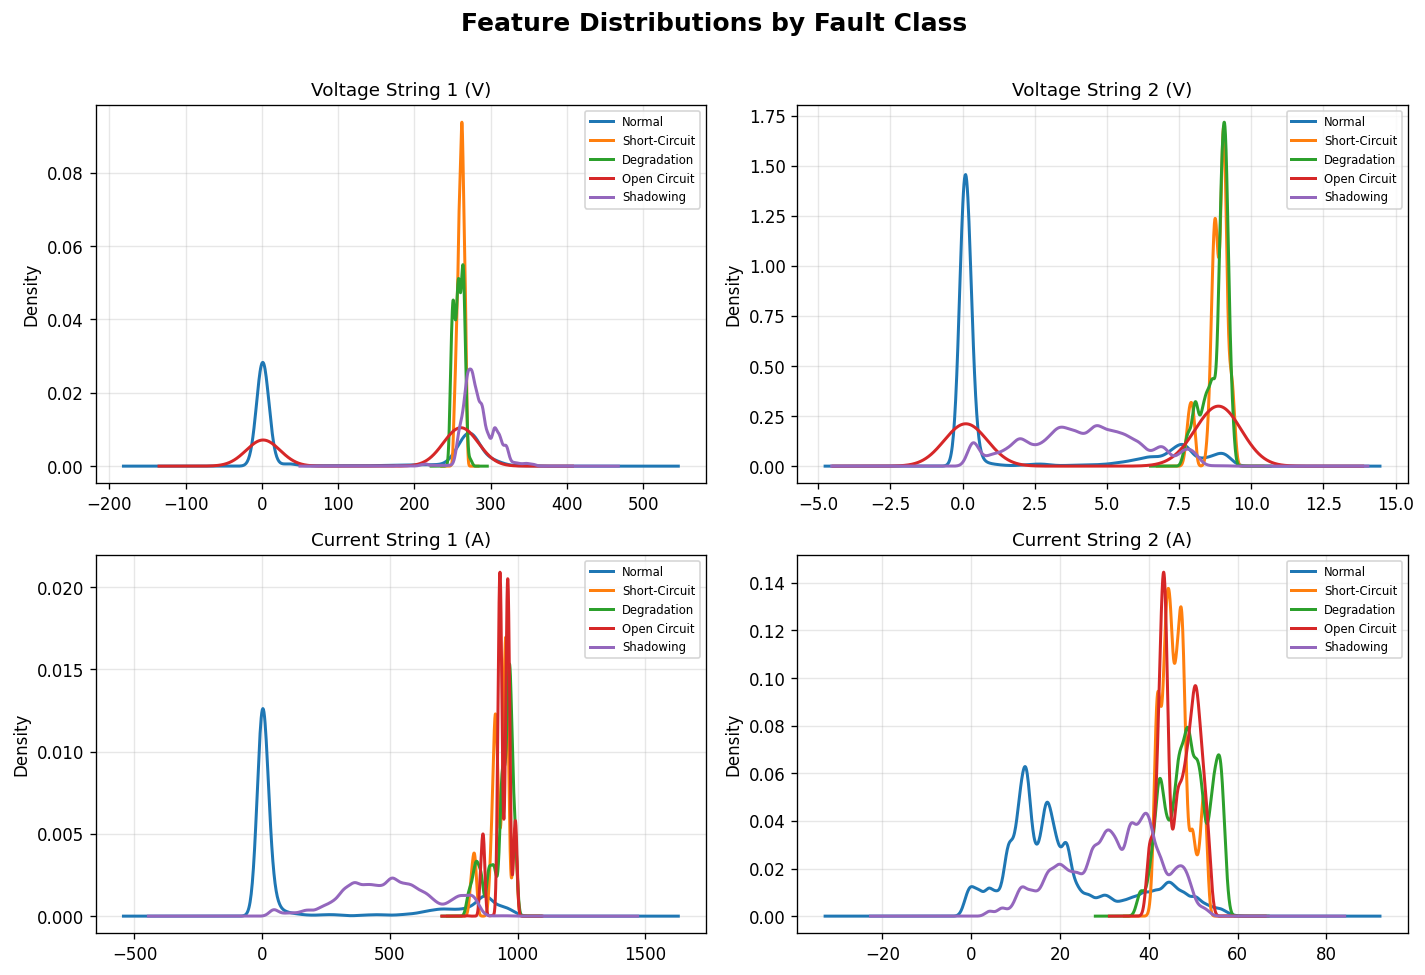

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Fault Class', fontsize=15, fontweight='bold', y=1.01)

features = ['vdc1', 'idc1', 'irr', 'pvt']
feat_labels = [
    'Voltage String 1 (V)', 'Voltage String 2 (V)',
    'Current String 1 (A)', 'Current String 2 (A)',
    'Irradiance (W/m²)', 'PV Temperature (°C)'
]

for ax, feat, label in zip(axes.flat, features, feat_labels):
    for fault_id, group in df.groupby('fault'):
        group[feat].plot.kde(ax=ax, label=FAULT_LABELS[fault_id], linewidth=1.8)
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

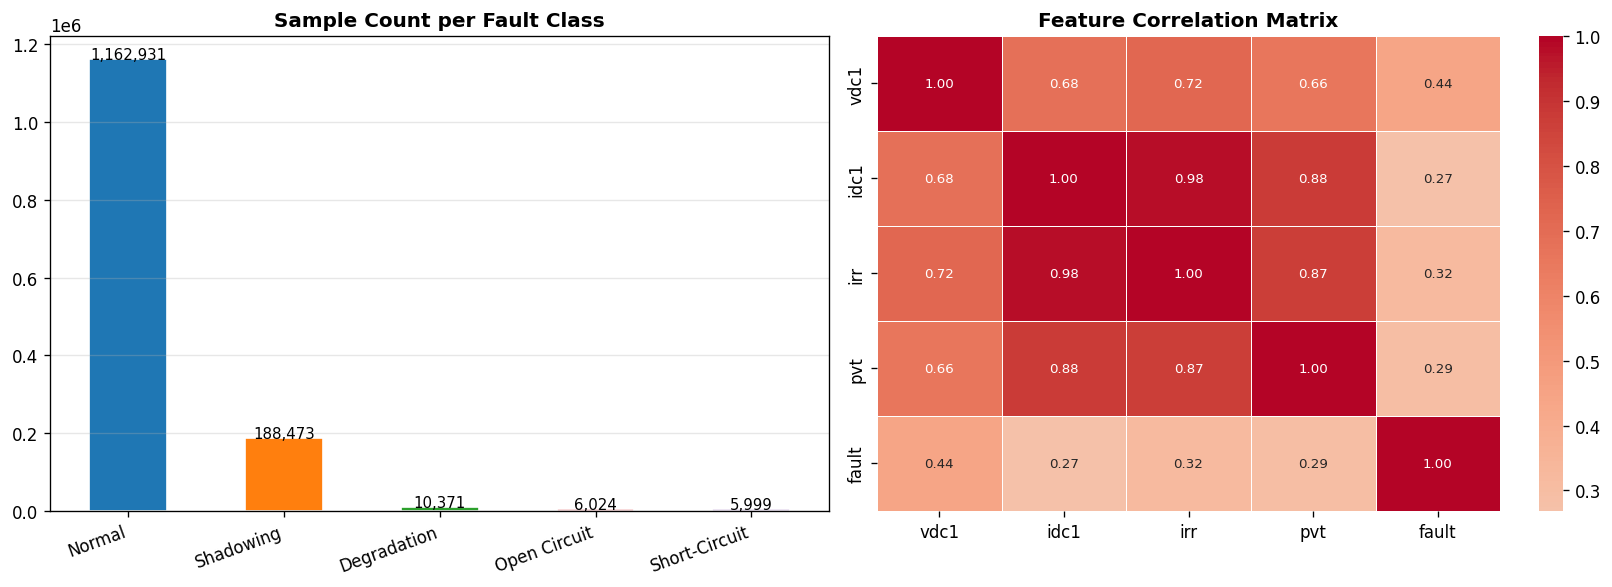

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class balance bar
counts.plot(kind='bar', ax=axes[0], color=sns.color_palette('tab10', 5), edgecolor='white')
axes[0].set_title('Sample Count per Fault Class', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_xticklabels(counts.index, rotation=20, ha='right')
axes[0].grid(axis='y', alpha=0.3)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 50),
                     ha='center', fontsize=9)

# Correlation heatmap
corr = df[features + ['fault']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', ax=axes[1], cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [14]:
df_fe = df.copy()

# --- Derived electrical features ---
eps = 1e-6  # avoid division by zero

df_fe['pdc1']    = df_fe['vdc1'] * df_fe['idc1']                        # Power String 1



# --- Efficiency / performance ratio ---
# Expected power ∝ irradiance; performance ratio compares actual vs expected
df_fe['perf_ratio1'] = df_fe['pdc1'] / (df_fe['irr'] + eps)

# --- Temperature-corrected irradiance ---
df_fe['irr_temp']   = df_fe['irr'] / (df_fe['pvt'] + eps)

FEATURE_COLS = ['vdc1', 'idc1', 'irr', 'pvt', 'pdc1', 'perf_ratio1', 'irr_temp']

print(f'Total features: {len(FEATURE_COLS)}')
df_fe[FEATURE_COLS].describe().round(3)

Total features: 7


,vdc1,idc1,irr,pvt,pdc1,perf_ratio1,irr_temp
count,1373798.000,1373798.000,1373798.000,1373798.000,1373798.000,1.373798e+06,1373798.000
mean,135.118,2.277,257.611,22.773,603.928,6.373234e+03,8.036
std,136.334,3.190,353.122,14.231,859.676,1.311869e+06,325.507
min,0.380,0.042,-0.038,-1.654,0.019,-1.051000e+00,-37930.145
25%,0.891,0.069,1.290,12.133,0.073,5.700000e-02,0.094
50%,37.776,0.114,1.736,18.490,3.361,5.960000e-01,0.420
75%,273.060,5.102,590.718,34.156,1409.855,2.432000e+00,16.510
max,363.974,9.655,1085.920,60.822,2495.546,3.352552e+08,183754.455


## 4. Data Cleaning & Splitting

In [15]:
# Drop rows with near-zero irradiance (nighttime — no meaningful signal)
night_mask = df_fe['irr'] < 10
print(f'Night/low-irradiance samples removed: {night_mask.sum()} ({night_mask.mean()*100:.1f}%)')
df_clean = df_fe[~night_mask].copy().reset_index(drop=True)

# Clip extreme outliers (beyond 1st/99th percentile)
for col in FEATURE_COLS:
    q1, q3 = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(q1, q3)

# ── TIME-BASED SPLIT (replaces random split) ──────────────────────────────
# Assign a day index based on position (dataset is ~1 sample/second = ~86400/day)
df_clean['day'] = np.arange(len(df_clean)) // 86400

total_days = df_clean['day'].max() + 1
split_day  = int(total_days * 0.75)  # train on 75% of days, test on last 25%

print(f'\nTotal days in dataset : {total_days}')
print(f'Training days         : 0 – {split_day - 1}')
print(f'Test days             : {split_day} – {total_days - 1}')

train_mask = df_clean['day'] < split_day
test_mask  = df_clean['day'] >= split_day

X_train = df_clean.loc[train_mask, FEATURE_COLS].values
X_test  = df_clean.loc[test_mask,  FEATURE_COLS].values
y_train = df_clean.loc[train_mask, 'fault'].values
y_test  = df_clean.loc[test_mask,  'fault'].values

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'\nTrain: {len(X_train):,} samples | Test: {len(X_test):,} samples')

# Verify no leakage — class distribution in each split
print('\nClass distribution — Train:')
for k, v in zip(*np.unique(y_train, return_counts=True)):
    print(f'  {FAULT_LABELS[k]:<15} {v:>6}')
print('\nClass distribution — Test:')
for k, v in zip(*np.unique(y_test, return_counts=True)):
    print(f'  {FAULT_LABELS[k]:<15} {v:>6}')

# Drop rows with near-zero irradiance (nighttime — no meaningful signal)
night_mask = df_fe['irr'] < 10
print(f'Night/low-irradiance samples removed: {night_mask.sum()} ({night_mask.mean()*100:.1f}%)')
df_clean = df_fe[~night_mask].copy().reset_index(drop=True)

# Clip extreme outliers (beyond 3 IQR)
for col in FEATURE_COLS:
    q1, q3 = df_clean[col].quantile([0.01, 0.99])
    df_clean[col] = df_clean[col].clip(q1, q3)

X = df_clean[FEATURE_COLS].values
y = df_clean['fault'].values

print(f'\nCleaned dataset: {X.shape[0]} samples × {X.shape[1]} features')
print('Class distribution after cleaning:')
for k, v in zip(*np.unique(y, return_counts=True)):
    print(f'  {FAULT_LABELS[k]:<15} {v:>6}')

Night/low-irradiance samples removed: 733952 (53.4%)

Total days in dataset : 8
Training days         : 0 – 5
Test days             : 6 – 7

Train: 518,400 samples | Test: 121,446 samples

Class distribution — Train:
  Normal          342088
  Short-Circuit     2458
  Degradation       6917
  Open Circuit      2410
  Shadowing       164527

Class distribution — Test:
  Normal           86891
  Short-Circuit     3541
  Degradation       3454
  Open Circuit      3614
  Shadowing        23946
Night/low-irradiance samples removed: 733952 (53.4%)

Cleaned dataset: 639846 samples × 7 features
Class distribution after cleaning:
  Normal          428979
  Short-Circuit     5999
  Degradation      10371
  Open Circuit      6024
  Shadowing       188473


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

Train: 511876 | Test: 127970


## 5. Model Training — Comparing Multiple Classifiers

In [18]:
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.svm import SVC as cuSVC

models = {
    'Random Forest': cuRF(        
        n_estimators=300,
        max_depth=10,             
        random_state=42
    ),
    'XGBoost': xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss',
        tree_method='hist', device='cuda',
        random_state=42
    ),
    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        class_weight='balanced', random_state=42,
        min_data_in_leaf=20,
        num_leaves=63,
        verbose=-1

    ),
    'SVM (RBF)': cuSVC(            
        kernel='rbf', C=10,
        probability=True,
    ),
}

results = {}

from sklearn.model_selection import TimeSeriesSplit
cv = TimeSeriesSplit(n_splits=5)

print('Training and cross-validating models...\n')
for name, model in models.items():
    Xtr = X_train_sc if name == 'SVM (RBF)' else X_train
    Xte = X_test_sc  if name == 'SVM (RBF)' else X_test

    # 5-fold CV on training set
    cv_scores = cross_val_score(model, Xtr, y_train, cv=cv,
                            scoring='f1_macro', n_jobs=1)  # ← 1 not -1
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro')

    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'test_acc': acc,
        'test_f1': f1,
        'X_test': Xte
    }

    print(f'[{name}]')
    print(f'  CV F1-macro:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
    print(f'  Test Accuracy: {acc:.4f}  |  Test F1-macro: {f1:.4f}')
    print()

Training and cross-validating models...

[Random Forest]
  CV F1-macro:   0.6303 ± 0.0073
  Test Accuracy: 0.9494  |  Test F1-macro: 0.6254

[XGBoost]
  CV F1-macro:   0.9449 ± 0.0115
  Test Accuracy: 0.9881  |  Test F1-macro: 0.9569

[LightGBM]
  CV F1-macro:   0.9311 ± 0.0039
  Test Accuracy: 0.9857  |  Test F1-macro: 0.9355

[SVM (RBF)]
  CV F1-macro:   0.4667 ± 0.0023
  Test Accuracy: 0.8871  |  Test F1-macro: 0.4633



In [19]:
# Summary table
summary = pd.DataFrame([
    {
        'Model': name,
        'CV F1-macro': f"{v['cv_f1_mean']:.4f} ± {v['cv_f1_std']:.4f}",
        'Test Accuracy': f"{v['test_acc']:.4f}",
        'Test F1-macro': f"{v['test_f1']:.4f}"
    }
    for name, v in results.items()
])
summary.set_index('Model', inplace=True)
print('=== Model Comparison Summary ===')
print(summary.to_string())

=== Model Comparison Summary ===
                   CV F1-macro Test Accuracy Test F1-macro
Model                                                     
Random Forest  0.6303 ± 0.0073        0.9494        0.6254
XGBoost        0.9449 ± 0.0115        0.9881        0.9569
LightGBM       0.9311 ± 0.0039        0.9857        0.9355
SVM (RBF)      0.4667 ± 0.0023        0.8871        0.4633


## 6. Best Model — Detailed Evaluation

In [20]:
# Pick the best model by test F1
best_name = max(results, key=lambda k: results[k]['test_f1'])
best = results[best_name]
y_pred_best = best['y_pred']

print(f' Best model: {best_name}')
print(f'   Test Accuracy : {best["test_acc"]:.4f}')
print(f'   Test F1-macro : {best["test_f1"]:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(
    y_test, y_pred_best,
    target_names=[FAULT_LABELS[i] for i in sorted(FAULT_LABELS)]
))

 Best model: XGBoost
   Test Accuracy : 0.9881
   Test F1-macro : 0.9569

=== Classification Report ===
               precision    recall  f1-score   support

       Normal       0.99      0.99      0.99     85796
Short-Circuit       0.94      0.90      0.92      1200
  Degradation       0.94      0.91      0.93      2074
 Open Circuit       0.96      0.96      0.96      1205
    Shadowing       0.99      0.98      0.99     37695

     accuracy                           0.99    127970
    macro avg       0.96      0.95      0.96    127970
 weighted avg       0.99      0.99      0.99    127970



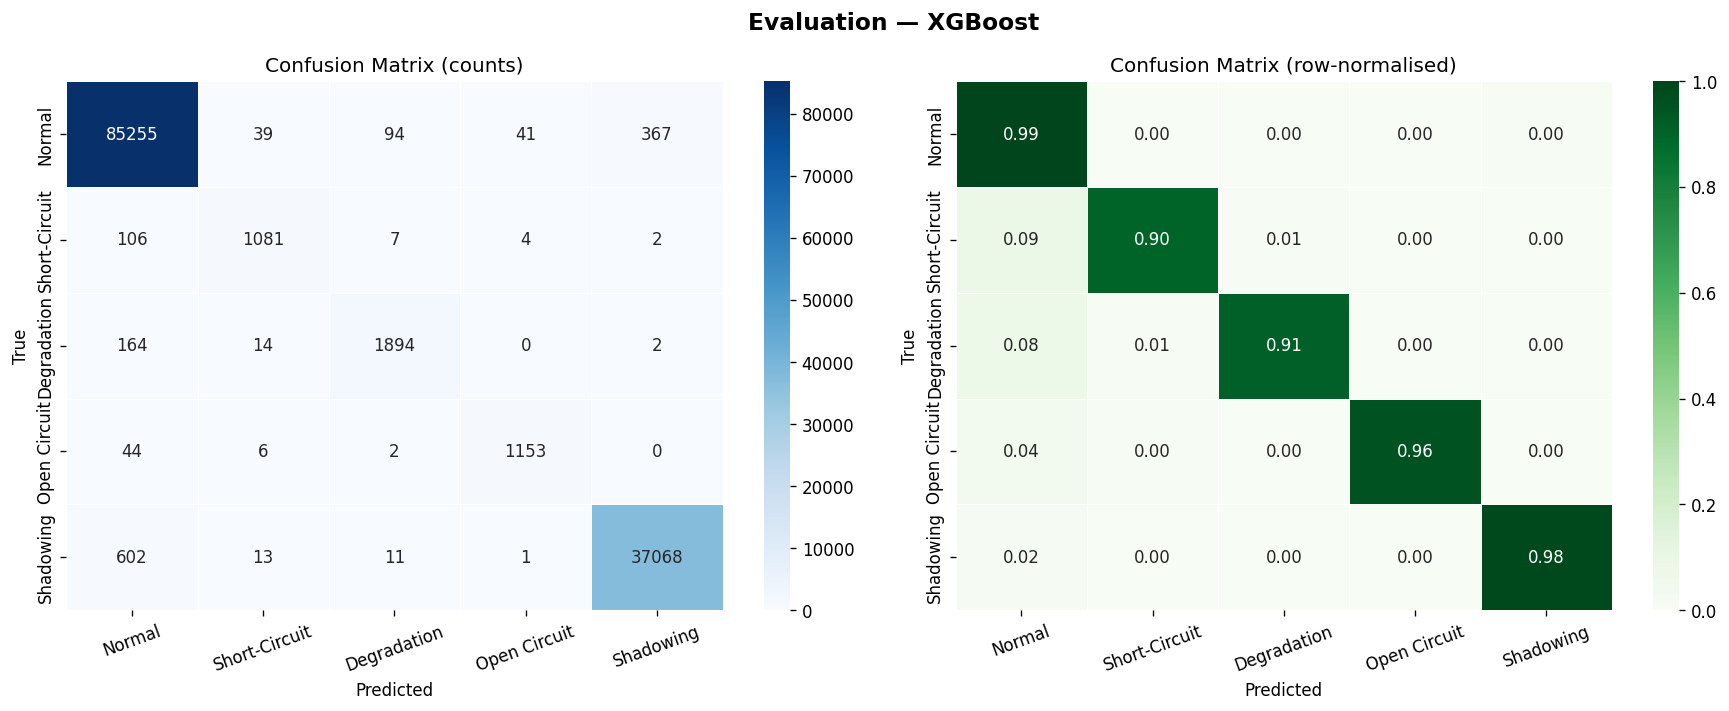

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(f'Evaluation — {best_name}', fontsize=14, fontweight='bold')

class_names = [FAULT_LABELS[i] for i in sorted(FAULT_LABELS)]

# Confusion matrix (counts)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names,
            cmap='Blues', linewidths=0.5)
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=20)

# Confusion matrix (normalised)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names,
            cmap='Greens', linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (row-normalised)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 7. Feature Importance

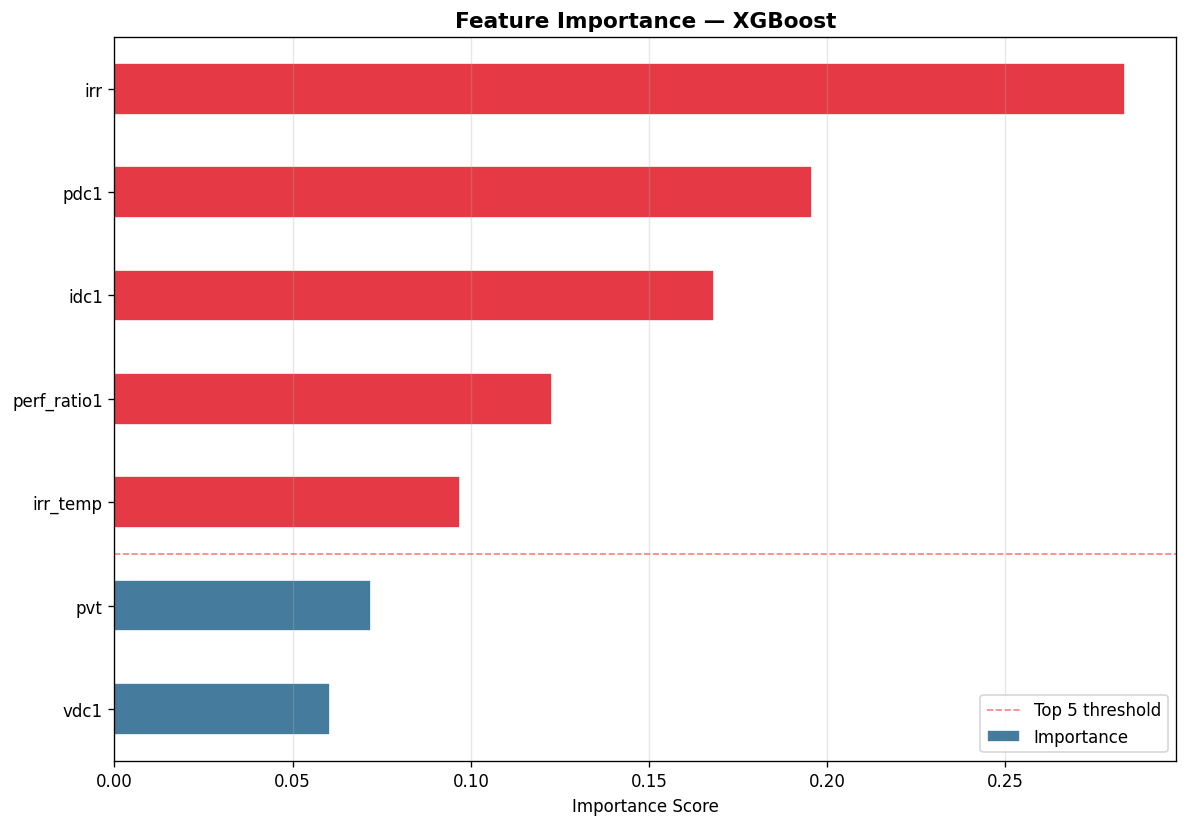

Top 5 most important features:
  irr                 0.2837
  pdc1                0.1958
  idc1                0.1683
  perf_ratio1         0.1227
  irr_temp            0.0969


In [22]:
# Feature importance (for tree-based models)
model_obj = best['model']

if hasattr(model_obj, 'feature_importances_'):
    importances = model_obj.feature_importances_
    fi_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = ['#e63946' if i >= len(fi_df) - 5 else '#457b9d'
              for i in range(len(fi_df))]
    fi_df['Importance'].plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_yticks(range(len(fi_df)))
    ax.set_yticklabels(fi_df['Feature'])
    ax.set_title(f'Feature Importance — {best_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)
    ax.axhline(len(fi_df) - 5 - 0.5, color='red', linestyle='--',
               linewidth=1, alpha=0.5, label='Top 5 threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()

    print('Top 5 most important features:')
    for _, row in fi_df.tail(5).iloc[::-1].iterrows():
        print(f'  {row["Feature"]:<18}  {row["Importance"]:.4f}')
else:
    print(f'Feature importance not available for {best_name}.')

## 8. Visualising Predictions on a Time Segment

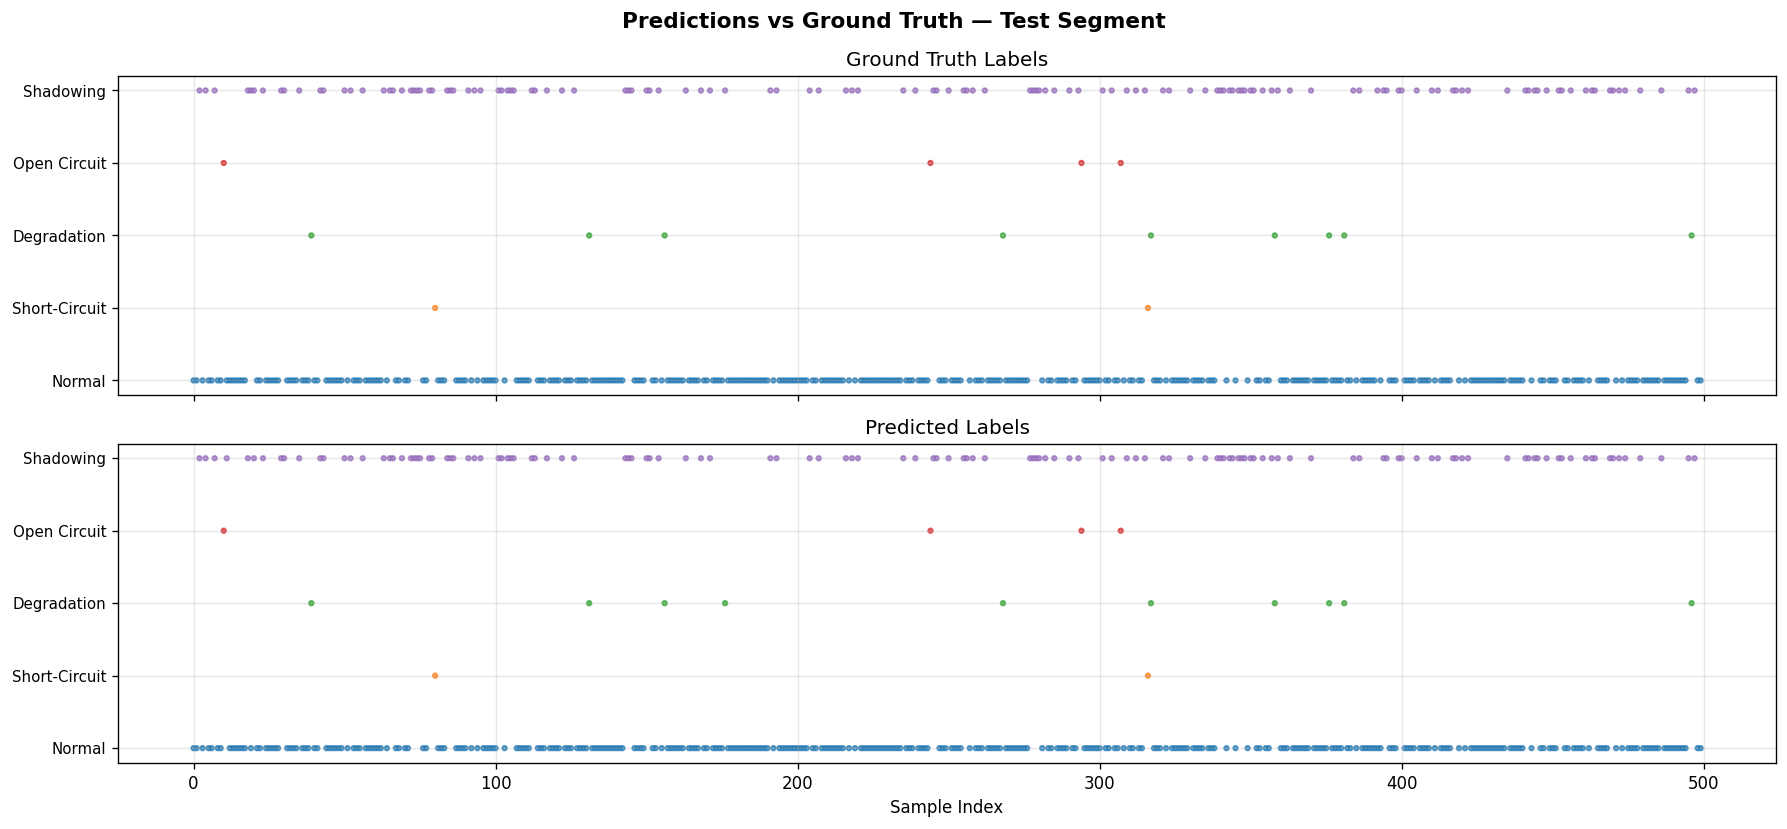

In [25]:
# Reconstruct a time-ordered slice for a visual sanity check
test_idx = np.arange(len(y_test))
segment = slice(0, min(500, len(y_test)))
y_true_seg = y_test[segment]
y_pred_seg = y_pred_best[segment]
x_seg = best['X_test'][segment]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
fig.suptitle('Predictions vs Ground Truth — Test Segment', fontsize=13, fontweight='bold')

colors_true = [f'C{y}' for y in y_true_seg]
colors_pred = [f'C{y}' for y in y_pred_seg]

ax1.scatter(range(len(y_true_seg)), y_true_seg, c=colors_true, s=8, label='True', alpha=0.7)
ax1.set_yticks(list(FAULT_LABELS.keys()))
ax1.set_yticklabels(list(FAULT_LABELS.values()), fontsize=9)
ax1.set_title('Ground Truth Labels')
ax1.grid(alpha=0.3)

ax2.scatter(range(len(y_pred_seg)), y_pred_seg, c=colors_pred, s=8, label='Predicted', alpha=0.7)
ax2.set_yticks(list(FAULT_LABELS.keys()))
ax2.set_yticklabels(list(FAULT_LABELS.values()), fontsize=9)
ax2.set_title('Predicted Labels')
ax2.set_xlabel('Sample Index')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Save the Best Model

In [27]:
import joblib

# Save model and scaler together
artifact = {
    'model': best['model'],
    'scaler': scaler,
    'feature_cols': FEATURE_COLS,
    'fault_labels': FAULT_LABELS,
    'best_model_name': best_name,
    'test_accuracy': best['test_acc'],
    'test_f1_macro': best['test_f1'],
}

joblib.dump(artifact, 'pv_fault_classifier.pkl')
print('Model saved to pv_fault_classifier.pkl')

Model saved to pv_fault_classifier.pkl


## 10. Inference Example — Using the Saved Model

In [28]:
def predict_fault(vdc1, idc1, irr, pvt, artifact):
    """
    Predict solar panel fault from raw sensor readings (single string).

    Parameters
    ----------
    vdc1 : float  — String voltage (V)
    idc1 : float  — String current (A)
    irr  : float  — Irradiance (W/m²)
    pvt  : float  — PV module temperature (°C)
    artifact : dict — Loaded joblib artifact

    Returns
    -------
    dict with fault_id and fault_name
    """
    eps = 1e-6
    pdc1 = vdc1 * idc1
    row = {
        'vdc1': vdc1, 'idc1': idc1,
        'irr': irr, 'pvt': pvt,
        'pdc1': pdc1,
        'perf_ratio1': pdc1 / (irr + eps),
        'irr_temp': irr / (pvt + eps),
    }
    X_input = pd.DataFrame([row])[artifact['feature_cols']].values
    pred = artifact['model'].predict(X_input)[0]
    return {'fault_id': int(pred), 'fault_name': artifact['fault_labels'][int(pred)]}


# Load and test
artifact = joblib.load('pv_fault_classifier.pkl')

# Example: simulate a reading that looks like normal operation
result = predict_fault(
    vdc1=310, idc1=5.2,
    irr=800, pvt=45,
    artifact=artifact
)
print(f'Prediction → Fault ID: {result["fault_id"]}  |  {result["fault_name"]}')

# Example: open circuit — near-zero current
result2 = predict_fault(
    vdc1=310, idc1=0.02,
    irr=800, pvt=45,
    artifact=artifact
)
print(f'Prediction → Fault ID: {result2["fault_id"]}  |  {result2["fault_name"]}')

Prediction → Fault ID: 4  |  Shadowing
Prediction → Fault ID: 4  |  Shadowing


In [29]:
import joblib, os

os.makedirs('saved_models', exist_ok=True)

for name, v in results.items():
    artifact = {
        'model': v['model'],
        'scaler': scaler,
        'feature_cols': FEATURE_COLS,
        'fault_labels': FAULT_LABELS,
        'test_accuracy': v['test_acc'],
        'test_f1_macro': v['test_f1'],
    }
    filename = f"saved_models/{name.replace(' ', '_').replace('(', '').replace(')', '')}.pkl"
    joblib.dump(artifact, filename)
    print(f"Saved: {filename}  |  Acc: {v['test_acc']:.4f}  F1: {v['test_f1']:.4f}")

Saved: saved_models/Random_Forest.pkl  |  Acc: 0.9494  F1: 0.6254
Saved: saved_models/XGBoost.pkl  |  Acc: 0.9881  F1: 0.9569
Saved: saved_models/LightGBM.pkl  |  Acc: 0.9857  F1: 0.9355
Saved: saved_models/SVM_RBF.pkl  |  Acc: 0.8871  F1: 0.4633


## Summary

| Step | Details |
|------|---------|
| **Dataset** | 16 days, 2-string PV plant, 5 fault classes |
| **Raw features** | `vdc1`, `idc1`, `irr`, `pvt` |
| **Engineered features** | Power, imbalances, ratios, performance ratio, temp-corrected irradiance |
| **Models trained** | Random Forest, XGBoost, LightGBM, SVM (RBF) |
| **Evaluation** | 5-fold CV + hold-out test (80/20 stratified split) |
| **Metrics** | Accuracy, F1-macro, per-class precision/recall |
| **Output** | Saved `.pkl` artifact + `predict_fault()` inference function |

**Citation:**  
> Lazzaretti et al. (2020). *Monitoring System for Online Fault Detection and Classification in Photovoltaic Plants*. Sensors, 20(17), 4688. https://doi.org/10.3390/s20174688